# ENGG2112 Final Project
## Notebook 1: Data Cleaning & Merging

This notebook combines and cleans all three data sources:

- **Section 1** — Flight data (BTS via Kaggle)
- **Section 2** — Weather data (NOAA GHCN-Daily)
- **Section 3** — Calendar data (US holidays & travel windows)
- **Section 4** — Merge all three into the final modelling CSV

**Output:** `ord_flights_weather_calendar.csv` — direct input to Notebook 2.

> **Before running:** Place `Chicago Airport Weather Data.csv` (from NOAA) in the same folder.

## Section 0: Install & Import

In [1]:
import sys
!{sys.executable} -m pip install kagglehub holidays scikit-learn imbalanced-learn xgboost --quiet
print('All packages installed')

All packages installed


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports complete')

Imports complete


---
## Section 1: Flight Data Cleaning
**Source:** BTS On-Time Performance — Kaggle (patrickzel/flight-delay-and-cancellation-dataset-2019-2023)  
**Scope:** Chicago O'Hare (ORD) departures only, COVID period excluded (March 2020 – December 2021)

In [3]:
# 1.1 Download from Kaggle
import kagglehub
path = kagglehub.dataset_download('patrickzel/flight-delay-and-cancellation-dataset-2019-2023')
FILE_PATH = os.path.join(path, 'flights_sample_3m.csv')

print('Loading flight dataset — this may take ~30 seconds...')
df_raw = pd.read_csv(FILE_PATH, parse_dates=['FL_DATE'], low_memory=False)

print(f'Loaded:     {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Date range: {df_raw["FL_DATE"].min().date()} to {df_raw["FL_DATE"].max().date()}')
print(f'Years:      {sorted(df_raw["FL_DATE"].dt.year.unique())}')

100%|██████████| 140M/140M [00:01<00:00, 119MB/s] 

Extracting files...


Loading flight dataset — this may take ~30 seconds...
Loaded:     3,000,000 rows x 32 columns
Date range: 2019-01-01 to 2023-08-31
Years:      [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


In [4]:
# 1.2 Filter to ORD departures
# One airport gives a consistent operational and weather environment.
# ORD extreme seasonal weather maximises predictive signal in our features.
df_ord = df_raw[df_raw['ORIGIN'] == 'ORD'].copy()
print(f'ORD departures: {len(df_ord):,} rows')
print(df_ord['FL_DATE'].dt.year.value_counts().sort_index())

ORD departures: 122,296 rows
FL_DATE
2019    34600
2020    19343
2021    24446
2022    26511
2023    17396
Name: count, dtype: int64


In [5]:
# 1.3 Exclude COVID period (March 2020 - December 2021)
# Near-zero demand and ghost flights represent a structural break that
# does not reflect normal operations. We exclude this period entirely.
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-12-31')

df_ord = pd.concat([
    df_ord[df_ord['FL_DATE'] < COVID_START],
    df_ord[df_ord['FL_DATE'] > COVID_END]
], ignore_index=True)

print(f'After COVID exclusion: {len(df_ord):,} rows')
print(df_ord['FL_DATE'].dt.year.value_counts().sort_index())

After COVID exclusion: 83,677 rows
FL_DATE
2019    34600
2020     5170
2022    26511
2023    17396
Name: count, dtype: int64


In [6]:
# 1.4 Remove cancelled flights
# Cancelled flights have NaN for DEP_DELAY. Cancellation prediction is
# a separate problem outside this project scope.
# Diverted flights have a valid DEP_DELAY so we keep them.
n_cancelled = df_ord['CANCELLED'].sum()
print(f'Removing {n_cancelled:,} cancelled flights ({n_cancelled/len(df_ord)*100:.1f}%)')

df_ord = df_ord[df_ord['CANCELLED'] == 0].copy()
df_ord = df_ord.drop(columns=['CANCELLATION_CODE'])
print(f'Rows remaining: {len(df_ord):,}')

Removing 2,225.0 cancelled flights (2.7%)
Rows remaining: 81,452


In [7]:
# 1.5 Handle missing values
# DELAY_DUE_* columns: NaN means NOT caused by that factor (structurally
# zero in BTS data). Fill with 0 — do NOT use median imputation here.
delay_cause_cols = [
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]
df_ord[delay_cause_cols] = df_ord[delay_cause_cols].fillna(0)

# DEP_DELAY: drop rows where target is null (cannot impute a target variable)
before = len(df_ord)
df_ord = df_ord.dropna(subset=['DEP_DELAY'])
print(f'Dropped {before - len(df_ord)} rows with null DEP_DELAY')

df_ord['ARR_DELAY'] = df_ord['ARR_DELAY'].fillna(0)

# Operational columns: median imputation (EDA only, excluded from model as leakage)
for col in ['TAXI_OUT', 'TAXI_IN', 'ELAPSED_TIME', 'AIR_TIME']:
    df_ord[col] = df_ord[col].fillna(df_ord[col].median())

remaining = df_ord.isnull().sum()
print('Missing values after cleaning:')
print(remaining[remaining > 0] if remaining.sum() > 0 else '  None')

Dropped 0 rows with null DEP_DELAY
Missing values after cleaning:
WHEELS_ON    38
ARR_TIME     38
dtype: int64


In [8]:
# 1.6 Feature engineering
# All features below are derivable from information available at booking
# time (scheduled departure). None constitute data leakage.

# Time-of-day (CRS_DEP_TIME stored as HHMM integer, e.g. 1430 = 2:30pm)
df_ord['dep_hour'] = df_ord['CRS_DEP_TIME'].astype(int) // 100
df_ord['arr_hour'] = df_ord['CRS_ARR_TIME'].astype(int) // 100

# Calendar features
df_ord['day_of_week'] = df_ord['FL_DATE'].dt.dayofweek
df_ord['month']       = df_ord['FL_DATE'].dt.month
df_ord['year']        = df_ord['FL_DATE'].dt.year
df_ord['quarter']     = df_ord['FL_DATE'].dt.quarter
df_ord['day_of_year'] = df_ord['FL_DATE'].dt.dayofyear

# Demand / timing binary flags (Friday included in weekend)
df_ord['is_weekend']      = df_ord['day_of_week'].isin([4, 5, 6]).astype(int)
df_ord['is_morning_peak'] = df_ord['dep_hour'].isin(range(6, 10)).astype(int)
df_ord['is_evening_peak'] = df_ord['dep_hour'].isin(range(16, 20)).astype(int)
df_ord['is_red_eye']      = df_ord['dep_hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Season
def get_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'autumn'

df_ord['season'] = df_ord['month'].apply(get_season)

# High-demand period flags
df_ord['is_holiday_month']   = df_ord['month'].isin([7, 11, 12]).astype(int)
df_ord['is_thanksgiving_wk'] = (
    (df_ord['month'] == 11) & (df_ord['day_of_year'].between(318, 332))
).astype(int)
df_ord['is_xmas_period'] = (
    ((df_ord['month'] == 12) & (df_ord['FL_DATE'].dt.day >= 20)) |
    ((df_ord['month'] == 1)  & (df_ord['FL_DATE'].dt.day <= 5))
).astype(int)

# Route distance category
df_ord['distance_category'] = pd.cut(
    df_ord['DISTANCE'],
    bins=[0, 500, 1000, 1500, 9999],
    labels=['short', 'medium', 'long', 'ultra_long'],
    include_lowest=True
)

# Airport congestion proxies (based on scheduled flights, not leakage)
daily_vol  = df_ord.groupby('FL_DATE').size().reset_index(name='daily_dep_count')
hourly_vol = df_ord.groupby(['FL_DATE', 'dep_hour']).size().reset_index(name='hourly_dep_count')
df_ord = df_ord.merge(daily_vol,  on='FL_DATE', how='left')
df_ord = df_ord.merge(hourly_vol, on=['FL_DATE', 'dep_hour'], how='left')

print(f'Feature engineering complete. Columns: {df_ord.shape[1]}')

Feature engineering complete. Columns: 49


In [9]:
# 1.7 Create target variables
# Classification: delayed >= 15 min (standard BTS/FAA definition)
# Regression:     DEP_DELAY in minutes (used for delayed flights only)
df_ord['is_delayed'] = (df_ord['DEP_DELAY'] >= 15).astype(int)

print('Classification target distribution:')
print(df_ord['is_delayed'].value_counts())
print(f'Delay rate: {df_ord["is_delayed"].mean()*100:.1f}%')

Classification target distribution:
is_delayed
0    64064
1    17388
Name: count, dtype: int64
Delay rate: 21.3%


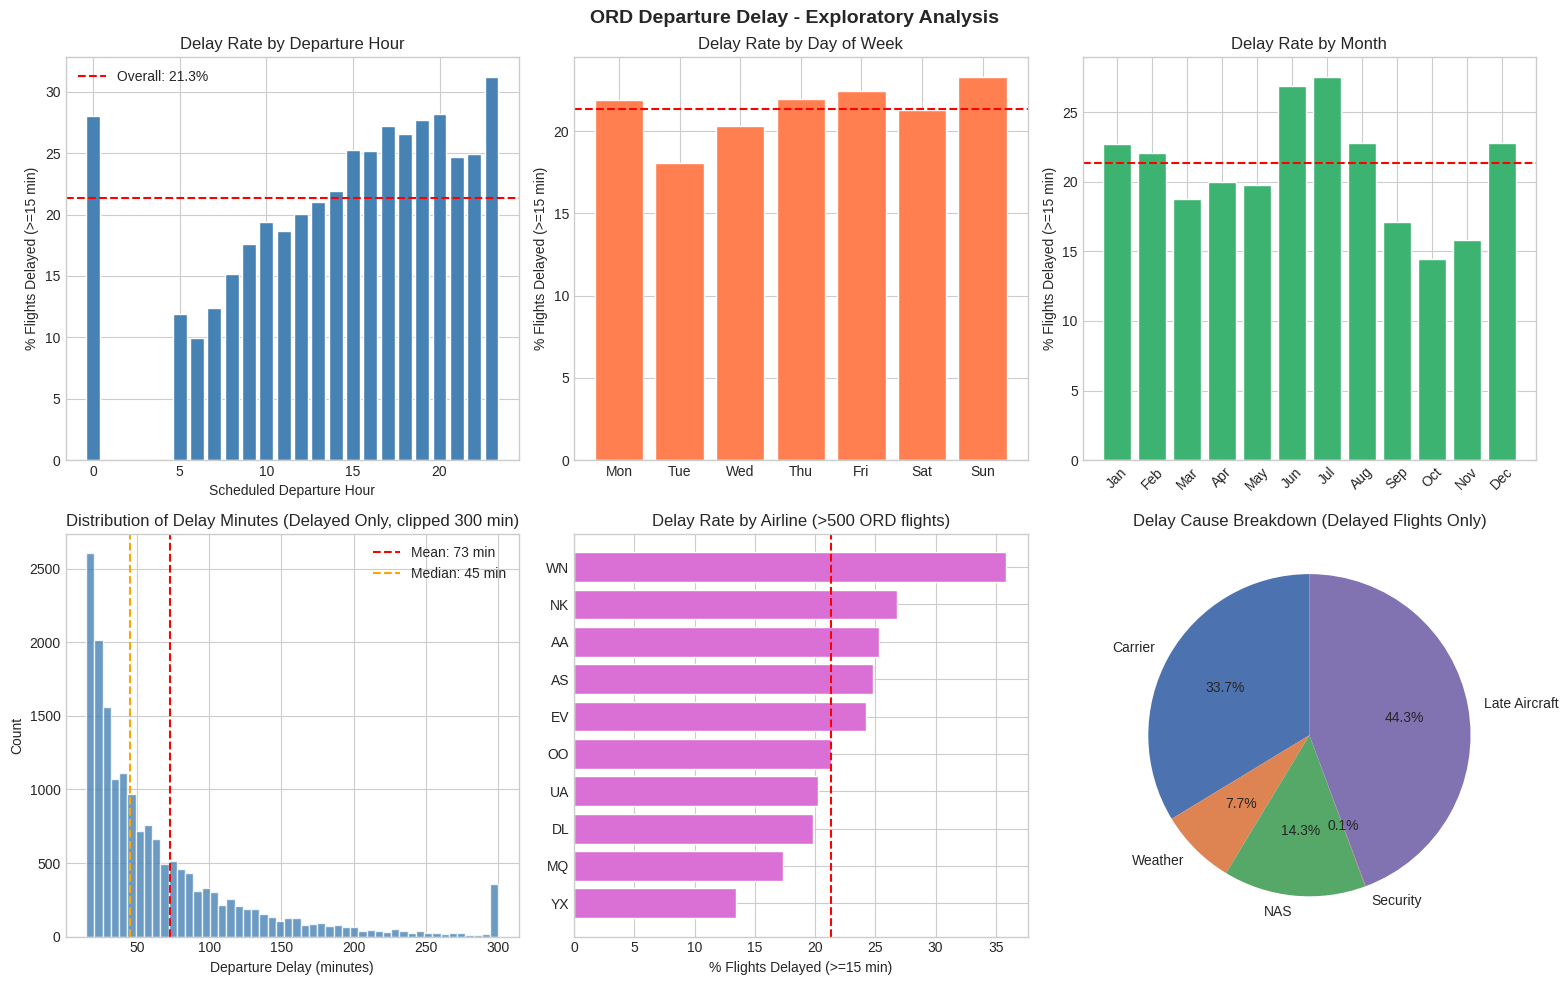

Saved: ord_eda.png


In [10]:
# 1.8 Exploratory data analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ORD Departure Delay - Exploratory Analysis', fontsize=14, fontweight='bold')

ax = axes[0, 0]
hourly_delay = df_ord.groupby('dep_hour')['is_delayed'].mean() * 100
ax.bar(hourly_delay.index, hourly_delay.values, color='steelblue', edgecolor='white')
ax.axhline(df_ord['is_delayed'].mean() * 100, color='red', linestyle='--',
           label=f"Overall: {df_ord['is_delayed'].mean()*100:.1f}%")
ax.set_title('Delay Rate by Departure Hour')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('% Flights Delayed (>=15 min)')
ax.legend()

ax = axes[0, 1]
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_delay = df_ord.groupby('day_of_week')['is_delayed'].mean() * 100
ax.bar(days, dow_delay.values, color='coral', edgecolor='white')
ax.axhline(df_ord['is_delayed'].mean() * 100, color='red', linestyle='--')
ax.set_title('Delay Rate by Day of Week')
ax.set_ylabel('% Flights Delayed (>=15 min)')

ax = axes[0, 2]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_delay = df_ord.groupby('month')['is_delayed'].mean() * 100
ax.bar(month_names, month_delay.values, color='mediumseagreen', edgecolor='white')
ax.axhline(df_ord['is_delayed'].mean() * 100, color='red', linestyle='--')
ax.set_title('Delay Rate by Month')
ax.set_ylabel('% Flights Delayed (>=15 min)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
delayed_only = df_ord[df_ord['is_delayed'] == 1]['DEP_DELAY']
ax.hist(delayed_only.clip(upper=300), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(delayed_only.mean(),   color='red',    linestyle='--', label=f'Mean: {delayed_only.mean():.0f} min')
ax.axvline(delayed_only.median(), color='orange', linestyle='--', label=f'Median: {delayed_only.median():.0f} min')
ax.set_title('Distribution of Delay Minutes (Delayed Only, clipped 300 min)')
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Count')
ax.legend()

ax = axes[1, 1]
airline_delay = (df_ord.groupby('AIRLINE_CODE')['is_delayed']
                       .agg(['mean','count'])
                       .query('count > 500')
                       .sort_values('mean'))
ax.barh(airline_delay.index, airline_delay['mean'] * 100, color='orchid', edgecolor='white')
ax.axvline(df_ord['is_delayed'].mean() * 100, color='red', linestyle='--')
ax.set_title('Delay Rate by Airline (>500 ORD flights)')
ax.set_xlabel('% Flights Delayed (>=15 min)')

ax = axes[1, 2]
delayed_df   = df_ord[df_ord['is_delayed'] == 1]
cause_totals = delayed_df[delay_cause_cols].sum()
cause_labels = ['Carrier','Weather','NAS','Security','Late Aircraft']
ax.pie(cause_totals, labels=cause_labels, autopct='%1.1f%%',
       colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'], startangle=90)
ax.set_title('Delay Cause Breakdown (Delayed Flights Only)')

plt.tight_layout()
plt.savefig('ord_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ord_eda.png')

In [11]:
# 1.9 Save cleaned flight data
print('=' * 55)
print('  DATASET SUMMARY - ORD DEPARTURES (COVID EXCLUDED)')
print('=' * 55)
print(f'Total flights:       {len(df_ord):,}')
print(f'Date range:          {df_ord["FL_DATE"].min().date()} to {df_ord["FL_DATE"].max().date()}')
print(f'Airlines:            {df_ord["AIRLINE_CODE"].nunique()}')
print(f'Unique destinations: {df_ord["DEST"].nunique()}')
print(f'Delay rate:          {df_ord["is_delayed"].mean()*100:.1f}%')

df_ord.to_csv('ord_flights_clean.csv', index=False)
print(f'Saved: ord_flights_clean.csv  {df_ord.shape}')

  DATASET SUMMARY - ORD DEPARTURES (COVID EXCLUDED)
Total flights:       81,452
Date range:          2019-01-01 to 2023-08-31
Airlines:            16
Unique destinations: 198
Delay rate:          21.3%
Saved: ord_flights_clean.csv  (81452, 50)


---
## Section 2: Weather Data Cleaning
**Source:** NOAA GHCN-Daily — Station USW00094846 (Chicago O'Hare)  
**File required:** `Chicago Airport Weather Data.csv` (download from https://www.ncei.noaa.gov)

In [12]:
# 2.1 Load NOAA data
weather_raw = pd.read_csv('Chicago Airport Weather Data.csv')
print(f'Shape:   {weather_raw.shape}')
print(f'Columns: {weather_raw.columns.tolist()}')
print('Missing values:')
print(weather_raw.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'Chicago Airport Weather Data.csv'

In [ ]:
# 2.2 Parse dates and drop identifier columns
# DATE is in D/M/YYYY format.
# STATION and NAME are identical for every row - no predictive value.
weather_raw['FL_DATE'] = pd.to_datetime(weather_raw['DATE'], format='%d/%m/%Y')

print('Date parsing check:')
print(weather_raw[['DATE', 'FL_DATE']].head(5).to_string())
print(f'Date range: {weather_raw["FL_DATE"].min().date()} to {weather_raw["FL_DATE"].max().date()}')

weather = weather_raw.drop(columns=['STATION', 'NAME', 'DATE'])

In [ ]:
# 2.3 Handle missing values
# PRCP, SNOW, SNWD: missing at ORD almost always means trace/none recorded.
#   Fill with 0 - standard NOAA preprocessing practice.
# TMAX, TMIN, AWND: temperature/wind change gradually day-to-day.
#   Forward-fill then backward-fill is appropriate.

print('Missing values before imputation:')
print(weather.isnull().sum())

for col in ['PRCP', 'SNOW', 'SNWD']:
    weather[col] = weather[col].fillna(0)

for col in ['TMAX', 'TMIN', 'AWND']:
    weather[col] = weather[col].ffill().bfill()

print('Missing values after imputation:')
print(weather.isnull().sum())

In [ ]:
# 2.4 Weather feature engineering
# Derived features that capture delay-relevant weather conditions
# more directly than raw measurements.

weather['temp_range'] = weather['TMAX'] - weather['TMIN']
weather['avg_temp']   = (weather['TMAX'] + weather['TMIN']) / 2

# Freezing conditions (ice on runways is a major delay driver at ORD)
weather['is_freezing']    = (weather['TMIN'] <= 32).astype(int)
weather['is_deep_freeze'] = (weather['TMAX'] <= 20).astype(int)

# Precipitation severity
weather['has_precip']    = (weather['PRCP'] > 0).astype(int)
weather['is_heavy_rain'] = (weather['PRCP'] > 0.5).astype(int)

# Snow severity (ORD has removal capacity but heavy accumulation still delays)
weather['has_snow']         = (weather['SNOW'] > 0).astype(int)
weather['is_moderate_snow'] = (weather['SNOW'] >= 1).astype(int)
weather['is_heavy_snow']    = (weather['SNOW'] >= 3).astype(int)
weather['has_snow_cover']   = (weather['SNWD'] > 0).astype(int)

# Wind severity (ORD crosswind limit approx 35 mph for commercial aircraft)
weather['is_windy']      = (weather['AWND'] >= 15).astype(int)
weather['is_very_windy'] = (weather['AWND'] >= 25).astype(int)

# Composite severe weather flag
weather['is_severe_weather'] = (
    (weather['is_heavy_snow']  == 1) |
    (weather['is_very_windy']  == 1) |
    (weather['is_deep_freeze'] == 1) |
    (weather['is_heavy_rain']  == 1)
).astype(int)

print(f'Severe weather days: {weather["is_severe_weather"].sum()} ({weather["is_severe_weather"].mean()*100:.1f}%)')
print(f'Snow days:           {weather["has_snow"].sum()}')
print(f'Freezing days:       {weather["is_freezing"].sum()}')
print(f'High wind days:      {weather["is_very_windy"].sum()}')

In [ ]:
# 2.5 Weather EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("NOAA Weather Data - Chicago O'Hare (ORD) 2019-2023", fontsize=13, fontweight='bold')

wp = weather.copy()
wp['month'] = wp['FL_DATE'].dt.month
wp['year']  = wp['FL_DATE'].dt.year
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax = axes[0, 0]
ax.fill_between(wp['FL_DATE'], wp['TMIN'], wp['TMAX'], alpha=0.4, color='steelblue', label='TMIN-TMAX range')
ax.plot(wp['FL_DATE'], wp['avg_temp'], color='steelblue', linewidth=0.8, label='Avg temp')
ax.axhline(32, color='red', linestyle='--', alpha=0.5, label='Freezing (32F)')
ax.set_title('Daily Temperature Range at ORD')
ax.set_ylabel('Temperature (F)')
ax.legend(fontsize=7)

ax = axes[0, 1]
monthly_wind = wp.groupby('month')['AWND'].mean()
ax.bar(month_names, monthly_wind.values, color='coral', edgecolor='white')
ax.axhline(15, color='red', linestyle='--', alpha=0.6, label='15 mph threshold')
ax.set_title('Monthly Average Wind Speed')
ax.set_ylabel('Wind Speed (mph)')
ax.tick_params(axis='x', rotation=45)
ax.legend()

ax = axes[0, 2]
ax.bar(month_names, wp.groupby('month')['SNOW'].sum().values, color='lightblue', edgecolor='steelblue')
ax.set_title('Total Monthly Snowfall (2019-2023)')
ax.set_ylabel('Total Snowfall (inches)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
ax.hist(wp[wp['PRCP'] > 0]['PRCP'].clip(upper=2), bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', label='Heavy rain threshold (0.5 in)')
ax.set_title('Precipitation Distribution (Rain/Snow days only)')
ax.set_xlabel('Precipitation (inches)')
ax.set_ylabel('Count')
ax.legend()

ax = axes[1, 1]
ax.bar(month_names, wp.groupby('month')['is_severe_weather'].sum().values, color='tomato', edgecolor='white')
ax.set_title('Severe Weather Days by Month')
ax.set_ylabel('Number of Severe Days')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 2]
annual_snow = wp.groupby('year')['SNOW'].sum()
ax.bar(annual_snow.index.astype(str), annual_snow.values, color='skyblue', edgecolor='steelblue')
ax.set_title('Total Annual Snowfall by Year')
ax.set_ylabel('Total Snowfall (inches)')

plt.tight_layout()
plt.savefig('weather_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weather_eda.png')

In [ ]:
# 2.6 Save cleaned weather data
weather.to_csv('noaa_weather_clean.csv', index=False)
print(f'Saved: noaa_weather_clean.csv  {weather.shape}')
print(f'Columns: {weather.columns.tolist()}')

---
## Section 3: Calendar Feature Generation
Generates US federal holiday flags and high-traffic travel window indicators  
based on FAA historical traffic data for ORD peak periods.

In [ ]:
# 3.1 Generate calendar features
dates  = pd.date_range(start='2019-01-01', end='2023-08-31', freq='D')
cal_df = pd.DataFrame({'date': dates})

# US Federal Holidays
us_holidays = {}
for year in [2019, 2020, 2022, 2023]:
    us_holidays.update(holidays.US(years=year))

cal_df['is_federal_holiday'] = cal_df['date'].dt.date.map(lambda d: 1 if d in us_holidays else 0)
cal_df['holiday_name']       = cal_df['date'].dt.date.map(lambda d: us_holidays.get(d, None))

# Holiday travel windows
# Airports are busiest in the days AROUND holidays, not just on them.
# Windows based on FAA historical traffic data for ORD.

def is_thanksgiving_window(date):
    # Wednesday before through Sunday after Thanksgiving (4th Thursday of November)
    if date.month != 11:
        return 0
    thursdays = [d for d in pd.date_range(f'{date.year}-11-01', f'{date.year}-11-30') if d.dayofweek == 3]
    thanksgiving = thursdays[3]
    return 1 if thanksgiving - pd.Timedelta(days=1) <= date <= thanksgiving + pd.Timedelta(days=3) else 0

def is_christmas_window(date):
    # Dec 20 to Jan 5
    return 1 if (date.month == 12 and date.day >= 20) or (date.month == 1 and date.day <= 5) else 0

def is_memorial_day_window(date):
    # Friday to Monday of last May weekend
    if date.month != 5:
        return 0
    last_monday = max(d for d in pd.date_range(f'{date.year}-05-01', f'{date.year}-05-31') if d.dayofweek == 0)
    return 1 if last_monday - pd.Timedelta(days=3) <= date <= last_monday else 0

def is_labor_day_window(date):
    # Friday to Monday of first September weekend
    if date.month != 9:
        return 0
    first_monday = min(d for d in pd.date_range(f'{date.year}-09-01', f'{date.year}-09-30') if d.dayofweek == 0)
    return 1 if first_monday - pd.Timedelta(days=3) <= date <= first_monday else 0

cal_df['is_thanksgiving_window'] = cal_df['date'].apply(is_thanksgiving_window)
cal_df['is_christmas_window']    = cal_df['date'].apply(is_christmas_window)
cal_df['is_memorial_day_window'] = cal_df['date'].apply(is_memorial_day_window)
cal_df['is_labor_day_window']    = cal_df['date'].apply(is_labor_day_window)

# Summer peak (June 15 - August 15: FAA designated peak summer period)
cal_df['is_summer_peak'] = cal_df['date'].apply(
    lambda d: 1 if (d.month == 6 and d.day >= 15) or d.month == 7 or (d.month == 8 and d.day <= 15) else 0
)

# Day before / after a federal holiday (often highest passenger volume)
holiday_dates = set(us_holidays.keys())
cal_df['is_day_before_holiday'] = cal_df['date'].apply(
    lambda d: 1 if (d + pd.Timedelta(days=1)).date() in holiday_dates else 0
)
cal_df['is_day_after_holiday'] = cal_df['date'].apply(
    lambda d: 1 if (d - pd.Timedelta(days=1)).date() in holiday_dates else 0
)

# Season
cal_df['season'] = cal_df['date'].dt.month.apply(get_season)

print(f'Calendar created: {len(cal_df)} days')
print(f'Thanksgiving windows: {cal_df["is_thanksgiving_window"].sum()} days')
print(f'Christmas windows:    {cal_df["is_christmas_window"].sum()} days')
print(f'Summer peak days:     {cal_df["is_summer_peak"].sum()} days')

In [ ]:
# 3.2 Save calendar data and spot-check
cal_df.to_csv('calendar_features.csv', index=False)
print(f'Saved: calendar_features.csv  {cal_df.shape}')

print('Sample (around Thanksgiving 2022):')
mask = (cal_df['date'] >= '2022-11-20') & (cal_df['date'] <= '2022-11-28')
print(cal_df[mask][['date','holiday_name','is_federal_holiday','is_thanksgiving_window']].to_string())

---
## Section 4: Merge All Three Datasets
Combines the three cleaned CSVs on `FL_DATE`.  
**Output:** `ord_flights_weather_calendar.csv` — direct input to Notebook 2 (Model Pipeline).

In [ ]:
# 4.1 Load and merge
flights_m  = pd.read_csv('ord_flights_clean.csv',   parse_dates=['FL_DATE'])
weather_m  = pd.read_csv('noaa_weather_clean.csv',  parse_dates=['FL_DATE'])
calendar_m = pd.read_csv('calendar_features.csv',   parse_dates=['date'])
calendar_m = calendar_m.rename(columns={'date': 'FL_DATE'})

# Left join: every flight row gets the weather for that day
df_merged = flights_m.merge(weather_m,  on='FL_DATE', how='left')
print(f'After weather merge:   {df_merged.shape}')

df_merged = df_merged.merge(calendar_m, on='FL_DATE', how='left')
df_merged['holiday_name'] = df_merged['holiday_name'].fillna('None')
print(f'After calendar merge:  {df_merged.shape}')

assert len(df_merged) == len(flights_m), f'Row count changed! {len(flights_m)} to {len(df_merged)}'
print(f'Row count preserved: {len(df_merged):,}')

In [ ]:
# 4.2 Resolve duplicate season column
# 'season' exists in both flights and calendar. Merge creates season_x
# and season_y - they are identical so keep one and drop the other.
if 'season_x' in df_merged.columns:
    df_merged = df_merged.rename(columns={'season_x': 'season'})
    df_merged = df_merged.drop(columns=['season_y'])
    print('Duplicate season column resolved')

# 4.3 Check for nulls introduced by merge
merged_nulls = df_merged.isnull().sum()
merged_nulls = merged_nulls[merged_nulls > 0]

if len(merged_nulls) == 0:
    print('No missing values from merge')
else:
    print('Missing values after merge:')
    print(merged_nulls)
    print('Filling nulls...')
    weather_cols  = [c for c in weather_m.columns  if c != 'FL_DATE']
    calendar_cols = [c for c in calendar_m.columns if c != 'FL_DATE']
    for col in weather_cols:
        if col in df_merged.columns:
            df_merged[col] = df_merged[col].ffill().bfill()
    for col in calendar_cols:
        if col in df_merged.columns and col != 'holiday_name':
            df_merged[col] = df_merged[col].fillna(0)
    df_merged['holiday_name'] = df_merged['holiday_name'].fillna('None')
    print('Nulls filled')

print(f'Total remaining null values: {df_merged.isnull().sum().sum()}')

In [ ]:
# 4.4 Save final merged dataset
df_merged.to_csv('ord_flights_weather_calendar.csv', index=False)

print('=' * 60)
print('  MERGE COMPLETE')
print('=' * 60)
print(f'  Final shape:  {df_merged.shape[0]:,} rows x {df_merged.shape[1]} columns')
print(f'  Output file:  ord_flights_weather_calendar.csv')
print(f'  Delay rate:   {df_merged["is_delayed"].mean()*100:.1f}%')
print(f'  Years:        {sorted(df_merged["year"].unique())}')
print()
print('Ready for Notebook 2 - Model Pipeline')